In [5]:
!pip install missingno
!pip install kaleido


[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import missingno as msno
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Load the data
df = pd.read_csv("data/manntol_einstaklingar_new.csv")

/tmp/ipykernel_324962/1880479758.py:13: DtypeWarning: Columns (4,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/manntol_einstaklingar_new.csv")


<Axes: >

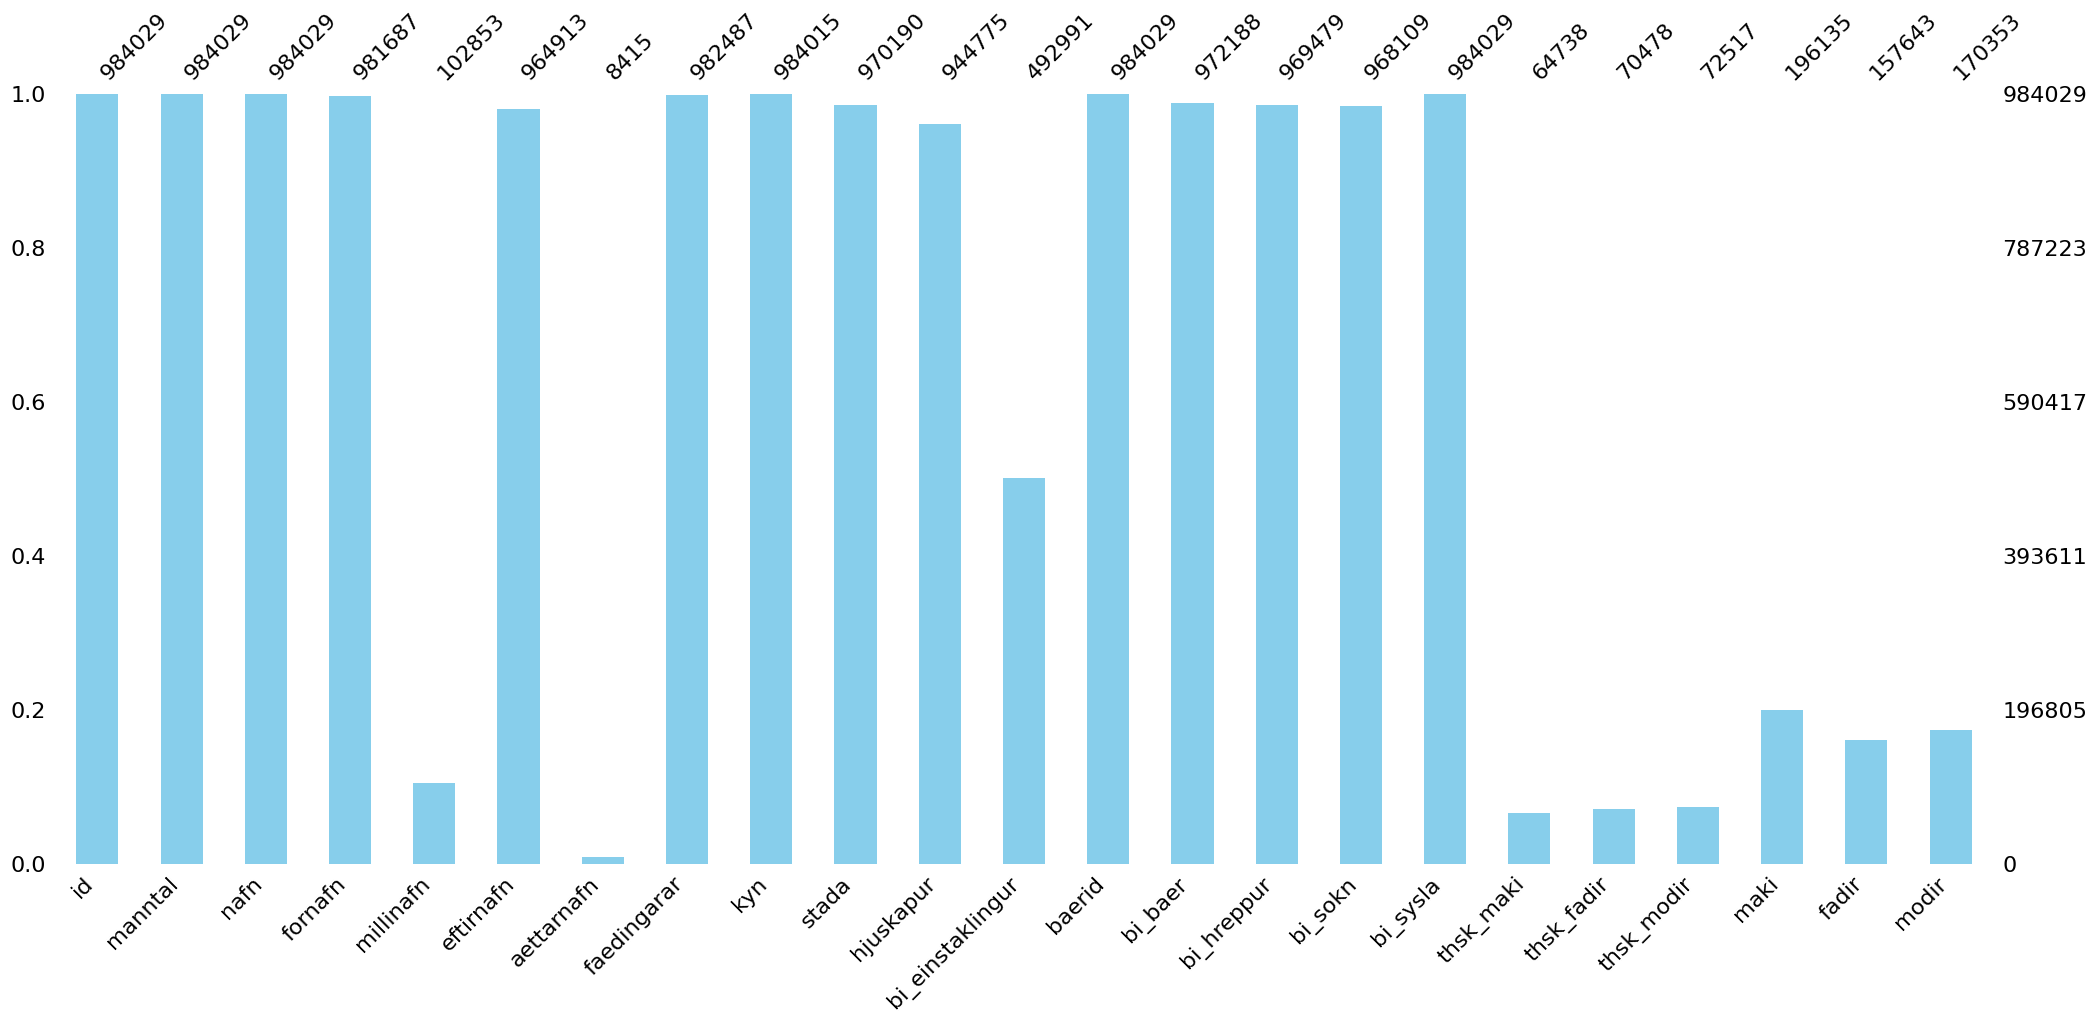

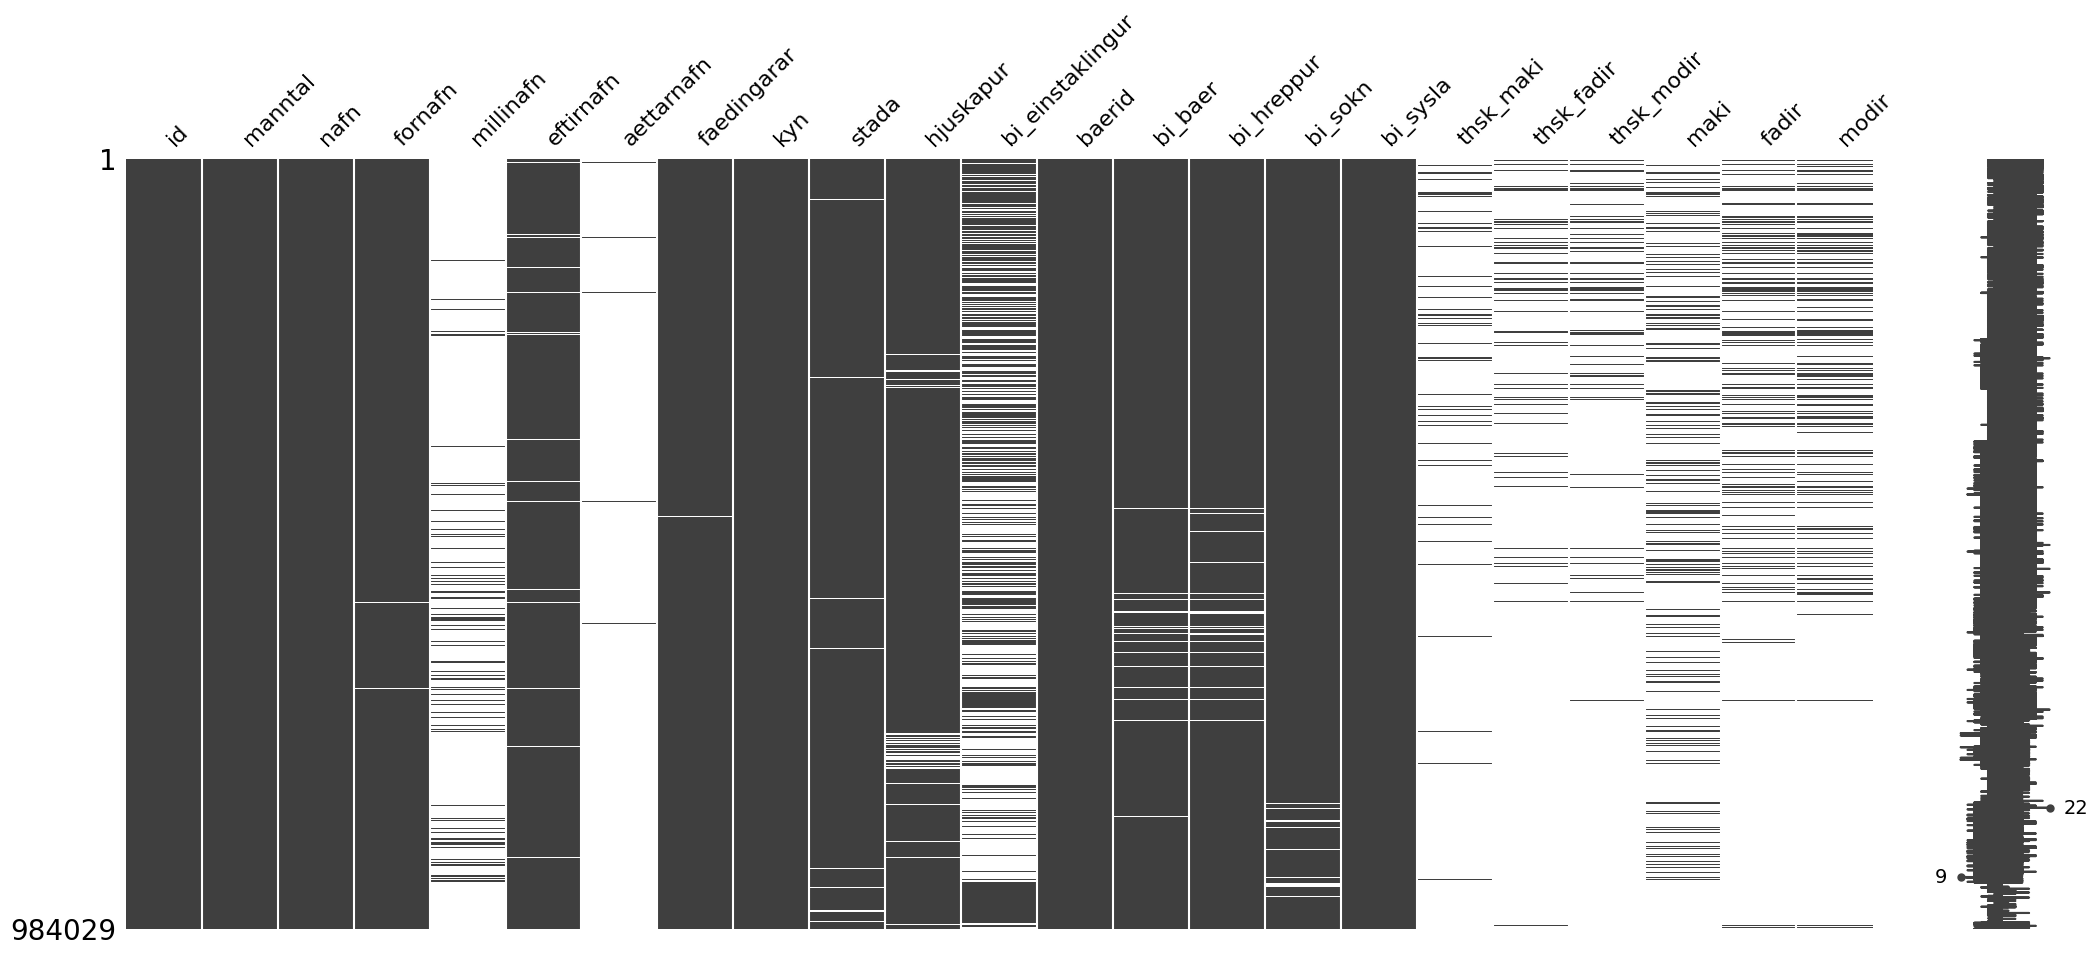

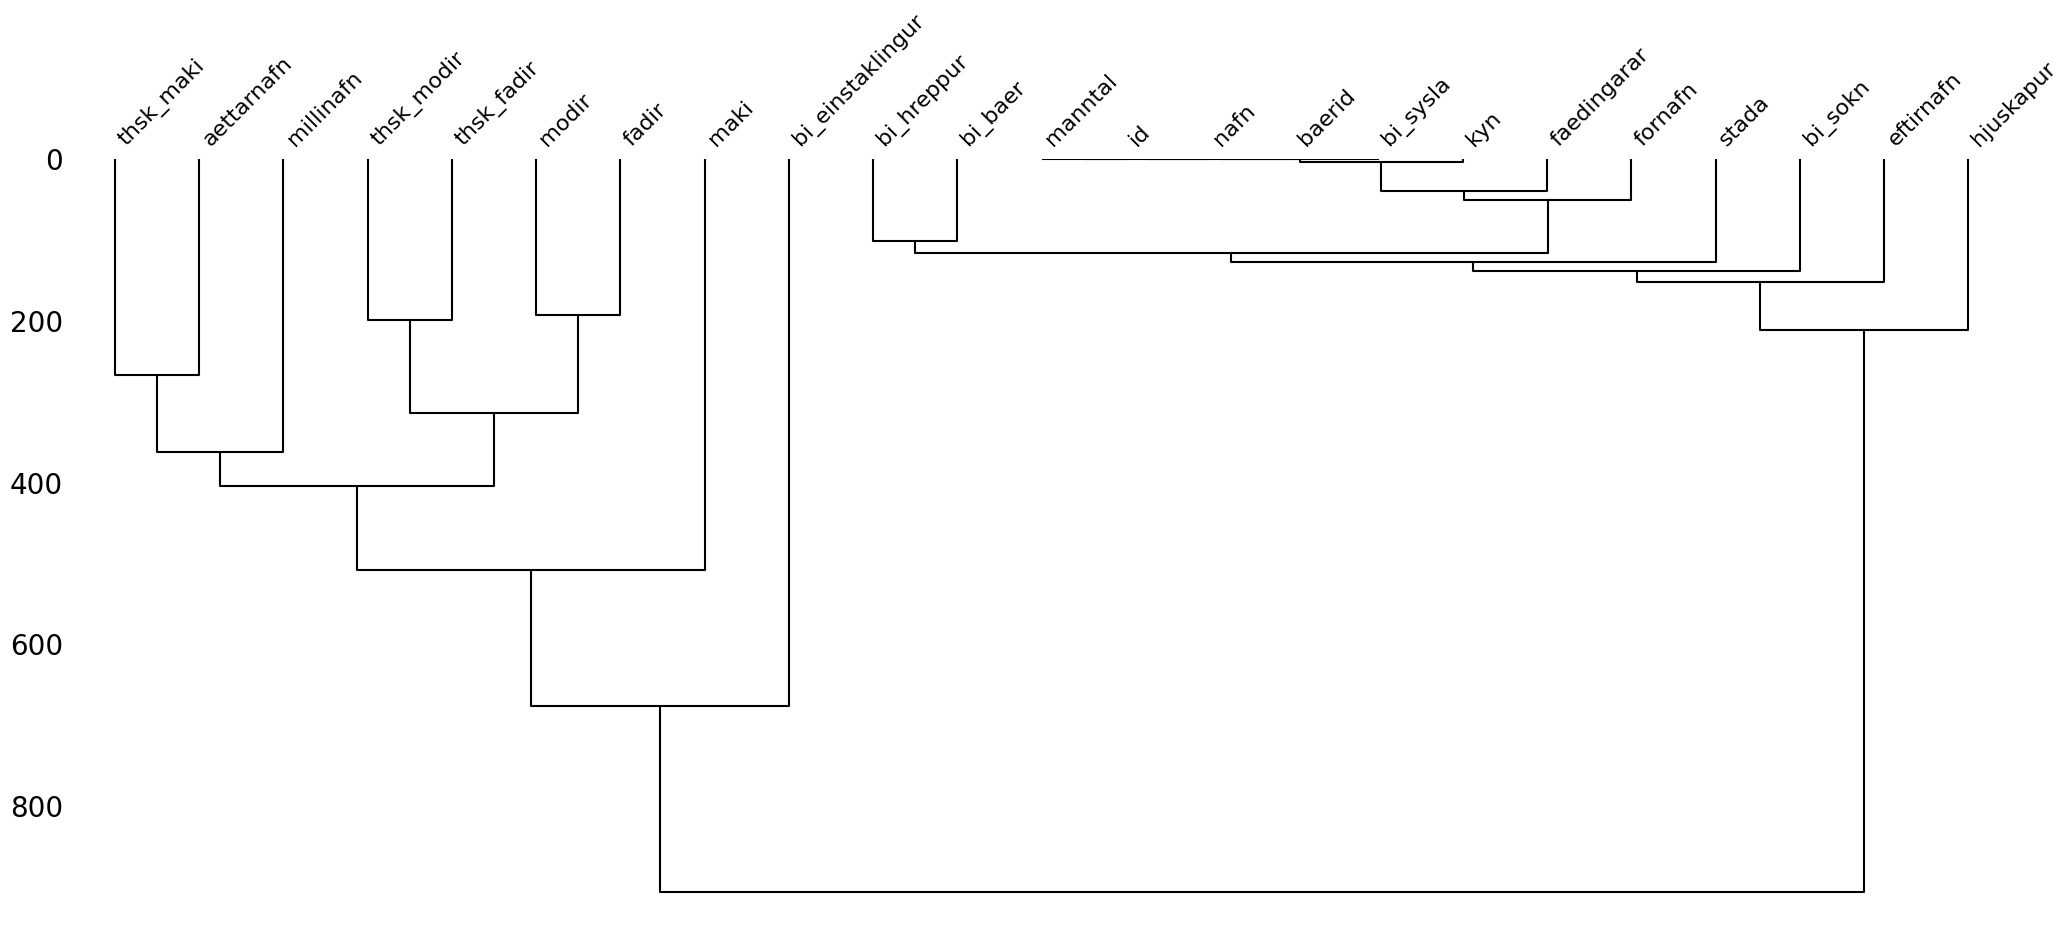

In [10]:
##############################
# Visualization : Missing Data Heatmap
##############################
# Use missingno to visualize missing data
# msno.heatmap(df, cmap='YlGnBu')
msno.bar(df, color='skyblue')
msno.matrix(df)
msno.dendrogram(df)

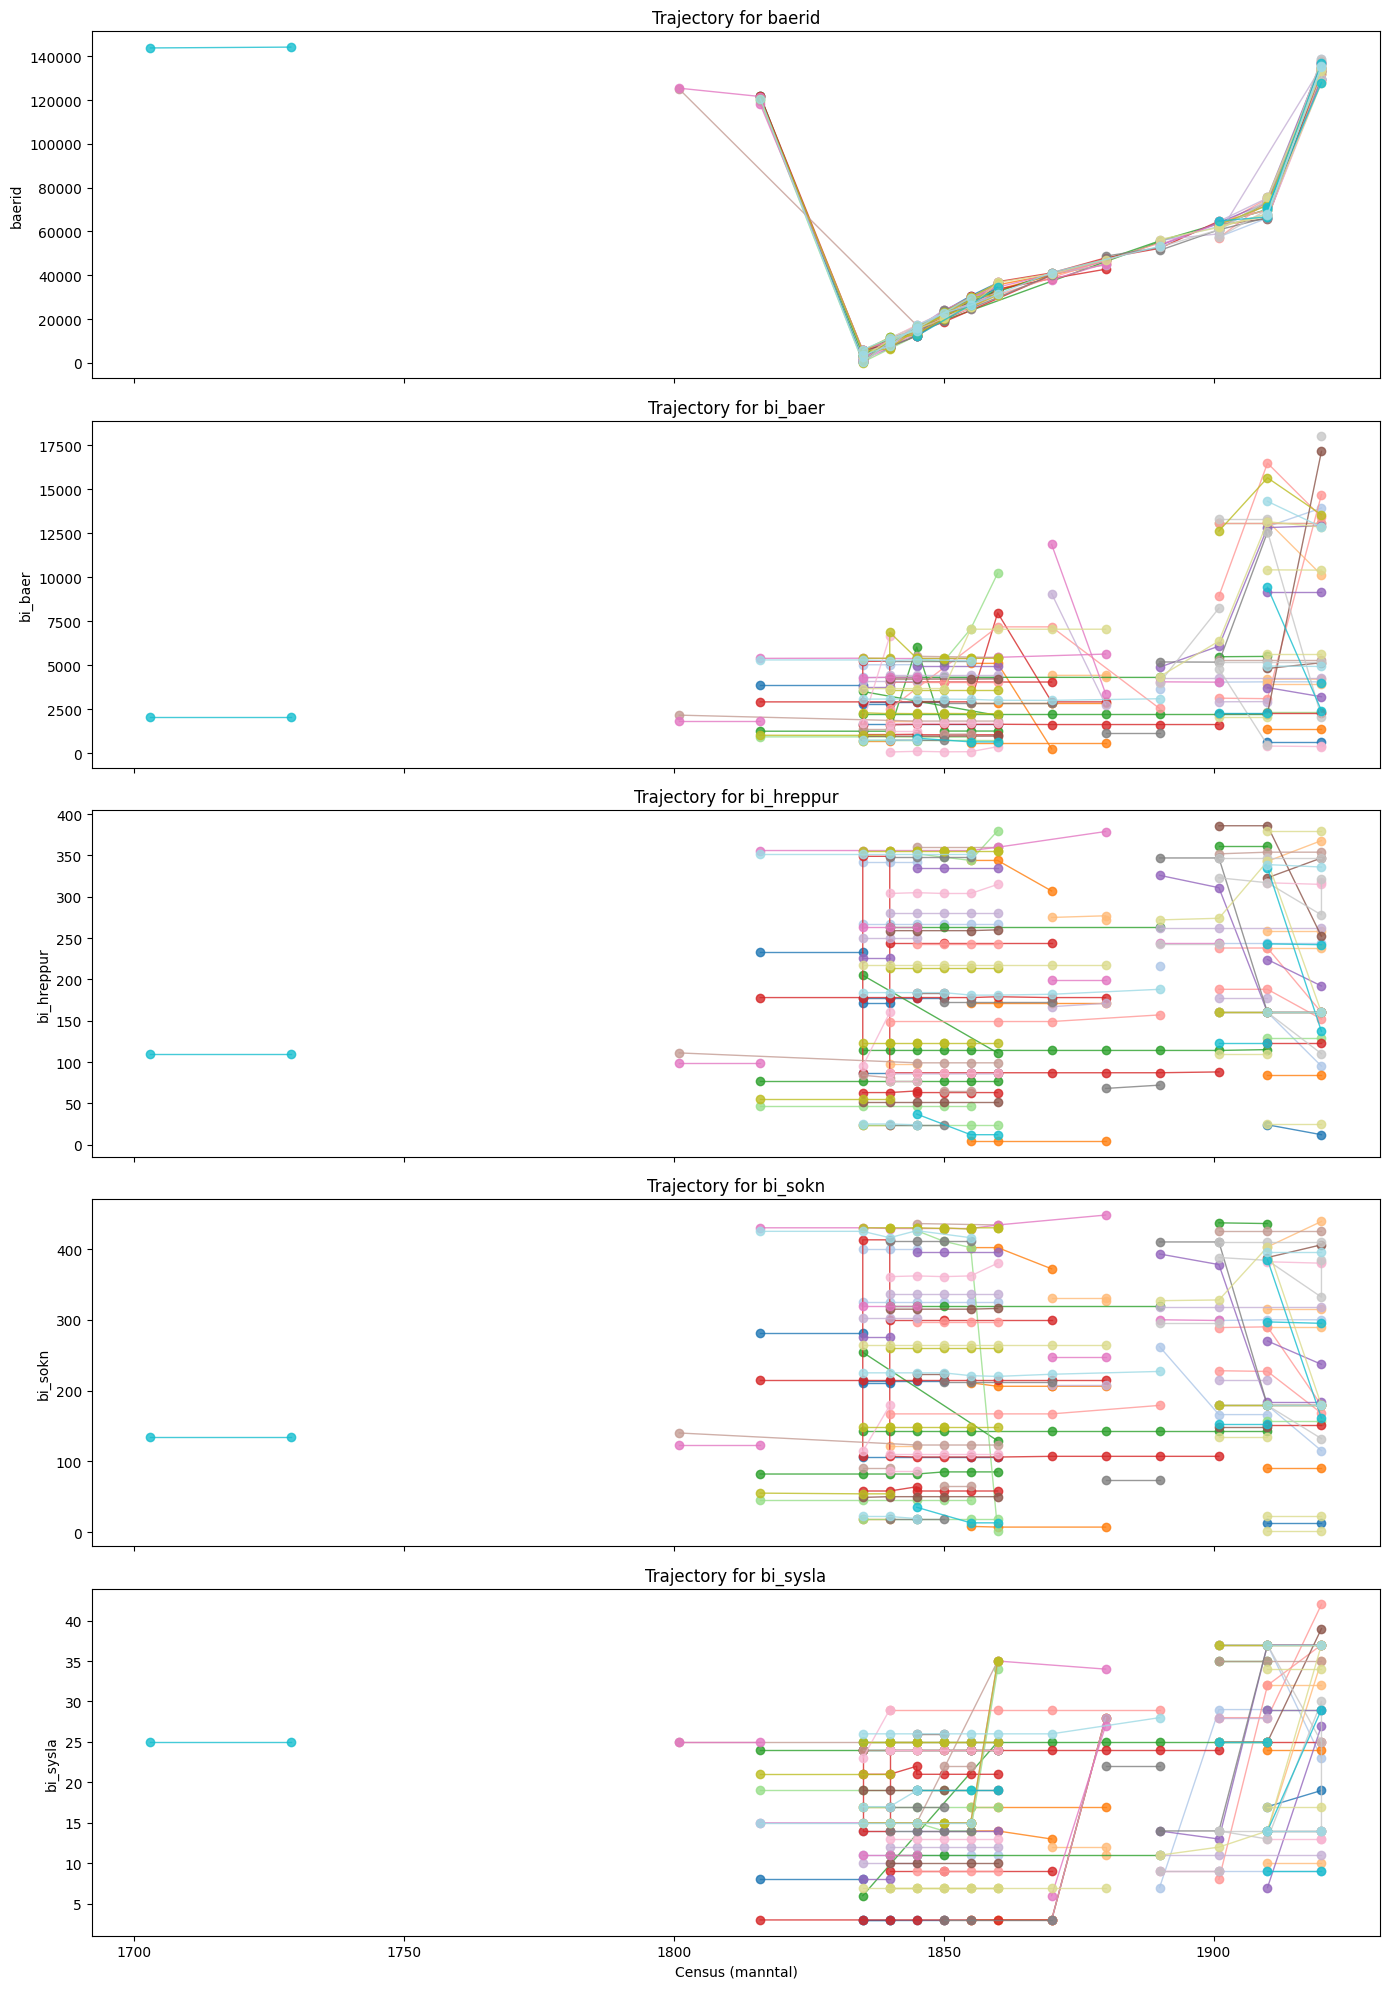

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import get_cmap
# -----------------------------------------------------------------------------
# Assume that df is already loaded and contains these columns:
#   bi_einstaklingur, manntal, stada, baerid, bi_baer, bi_hreppur, bi_sokn, bi_sysla, etc.
# -----------------------------------------------------------------------------

# Filter individuals who appear in more than one census record
df_multi = df.groupby('bi_einstaklingur').filter(lambda x: len(x) > 1)

# Define the geographic fields to examine
geo_vars = ['baerid', 'bi_baer', 'bi_hreppur', 'bi_sokn', 'bi_sysla']

# To ease plotting, sample a subset of individuals (e.g. 100)
sample_ids = np.random.choice(df_multi['bi_einstaklingur'].unique(), replace=False, size=100)

# Create a figure with 5 subplots (one per geographic variable)
fig, axs = plt.subplots(nrows=5, ncols=1, figsize=(14, 20), sharex=True)

# Create a colormap that will assign a distinct color to each individual
cmap = get_cmap('tab20', len(sample_ids))

# Loop through each geographic variable and plot trajectories
for i, var in enumerate(geo_vars):
    ax = axs[i]
    for j, bid in enumerate(sample_ids):
        sub = df_multi[df_multi['bi_einstaklingur'] == bid].sort_values('manntal')
        ax.plot(sub['manntal'], sub[var], marker='o', color=cmap(j),
                linewidth=1, alpha=0.8)
    ax.set_ylabel(var)
    ax.set_title(f"Trajectory for {var}")
    
# Set a common x-label
axs[-1].set_xlabel("Census (manntal)")

plt.tight_layout()
plt.show()


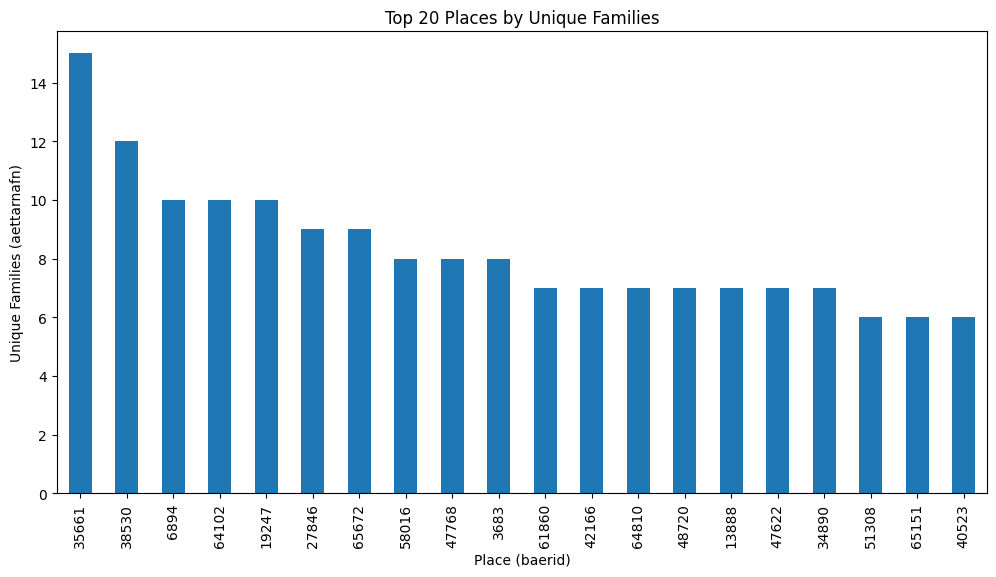

In [11]:

##############################
# Visualization: Families per Place
##############################
# Count unique families per place
families_per_place = df.groupby('baerid')['aettarnafn'].nunique().sort_values(ascending=False)
plt.figure(figsize=(12,6))
# Plot the top 20 places (adjust as needed)
families_per_place.head(20).plot(kind='bar')
plt.xlabel("Place (baerid)")
plt.ylabel("Unique Families (aettarnafn)")
plt.title("Top 20 Places by Unique Families")
plt.show()

In [7]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

def sankey_for_geo_sample(df, geo_var, sample_size=1000):
    """
    Build a Sankey diagram for a geographic variable using a random sample of individuals.
    Each node is labeled as 'manntal_geoValue' (e.g., '1801_5526'), and links represent the 
    number of individuals transitioning from one node to the next.
    The diagram is saved as a PNG file.
    
    Parameters:
      df (DataFrame): Must contain 'bi_einstaklingur', 'manntal', and geo_var.
      geo_var (str): The geographic variable (e.g., 'baerid').
      sample_size (int): Number of unique individuals to sample.
    """
    # Filter to individuals with more than one census record.
    df_multi = df.groupby('bi_einstaklingur').filter(lambda x: len(x) > 1).copy()
    df_multi.sort_values(['bi_einstaklingur', 'manntal'], inplace=True)
    
    # Sample a subset of individuals for faster processing.
    unique_ids = df_multi['bi_einstaklingur'].unique()
    sample_ids = np.random.choice(unique_ids, size=min(sample_size, len(unique_ids)), replace=False)
    df_sample = df_multi[df_multi['bi_einstaklingur'].isin(sample_ids)].copy()
    
    # Create a node label: combine census year and the geographic value.
    df_sample['node'] = df_sample['manntal'].astype(str) + "_" + df_sample[geo_var].astype(str)
    
    # For each individual, shift the 'node' column to get the target node.
    df_sample['target'] = df_sample.groupby('bi_einstaklingur')['node'].shift(-1)
    df_trans = df_sample.dropna(subset=['target'])
    
    # Aggregate transitions (i.e., count the number of individuals making each transition).
    trans_counts = df_trans.groupby(['node', 'target']).size().reset_index(name='value')
    
    # Create the list of unique nodes.
    nodes = pd.unique(trans_counts[['node', 'target']].values.ravel('K'))
    node_labels = list(nodes)
    node_map = {label: idx for idx, label in enumerate(node_labels)}
    
    # Map source and target labels to node IDs.
    trans_counts['source_id'] = trans_counts['node'].map(node_map)
    trans_counts['target_id'] = trans_counts['target'].map(node_map)
    
    # Build the Sankey diagram.
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=node_labels,
            color="blue"
        ),
        link=dict(
            source=trans_counts['source_id'],
            target=trans_counts['target_id'],
            value=trans_counts['value']
        )
    )])
    
    fig.update_layout(
        title_text=f"Sankey Diagram for {geo_var} (Census Transitions) using {len(sample_ids)} individuals",
        font_size=10,
        width=1200,
        height=700
    )
    
    output_filename = f"sankey_{geo_var}_sample.png"
    fig.write_image(output_filename)
    print(f"Saved Sankey diagram for {geo_var} to {output_filename} using {len(sample_ids)} individuals.")

# Define the geographic variables to examine.
geo_vars = ['baerid', 'bi_baer', 'bi_hreppur', 'bi_sokn', 'bi_sysla']

# Assume df is your loaded DataFrame that contains at least:
# 'bi_einstaklingur', 'manntal', and each variable in geo_vars.
for var in geo_vars:
    sankey_for_geo_sample(df[['bi_einstaklingur', 'manntal', var]], var, sample_size=1000)

Saved Sankey diagram for baerid to sankey_baerid_sample.png using 1000 individuals.
Saved Sankey diagram for bi_baer to sankey_bi_baer_sample.png using 1000 individuals.
Saved Sankey diagram for bi_hreppur to sankey_bi_hreppur_sample.png using 1000 individuals.
Saved Sankey diagram for bi_sokn to sankey_bi_sokn_sample.png using 1000 individuals.
Saved Sankey diagram for bi_sysla to sankey_bi_sysla_sample.png using 1000 individuals.


/tmp/ipykernel_288777/2250805907.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_traj = df_multi.groupby('bi_einstaklingur').apply(build_trajectory).reset_index()


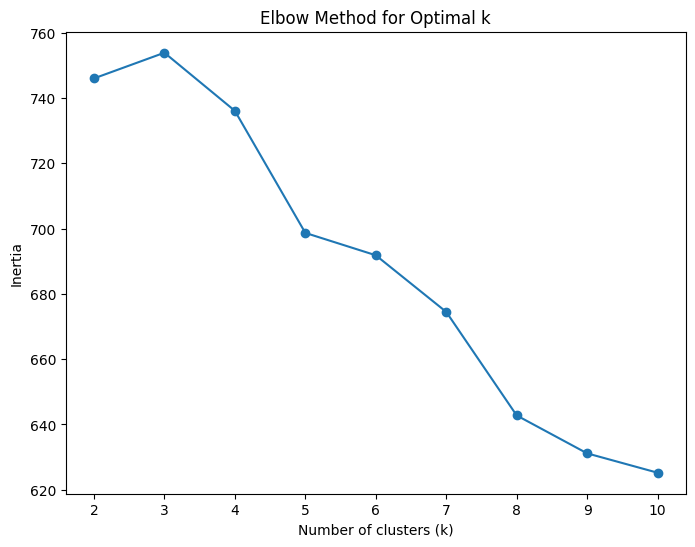

In [6]:
# Filter individuals appearing in more than one census record.
df_multi = df.groupby('bi_einstaklingur').filter(lambda x: len(x) > 1)

# Define a helper function to safely convert a value to an integer string or return 'NA'
def safe_int(val):
    return str(int(val)) if pd.notna(val) else "NA"

# Define a function to create a trajectory string for each individual.
def build_trajectory(group):
    # Sort records by census year (manntal)
    group_sorted = group.sort_values('manntal')
    # For each record, create a token concatenating geographic identifiers.
    # Here, we use safe_int() to handle missing values.
    tokens = group_sorted.apply(
        lambda row: f"BAERID_{row['baerid']}_BB_{safe_int(row['bi_baer'])}_BH_{safe_int(row['bi_hreppur'])}"
                    f"_BS_{safe_int(row['bi_sokn'])}_Bsys_{safe_int(row['bi_sysla'])}",
        axis=1
    )
    # Join tokens with a space to form the full trajectory.
    return " ".join(tokens)

# Group by individual and build a trajectory string.
df_traj = df_multi.groupby('bi_einstaklingur').apply(build_trajectory).reset_index()
df_traj.columns = ['bi_einstaklingur', 'trajectory']

# Vectorize the trajectories with TF-IDF.
vectorizer = TfidfVectorizer()
X_traj = vectorizer.fit_transform(df_traj['trajectory'])

# Use TruncatedSVD to reduce dimensions (works with sparse matrices) for clustering.
svd = TruncatedSVD(n_components=50, random_state=42)
X_clust = svd.fit_transform(X_traj)

# -----------------------------------------------------------------------------
# Clustering: Use the elbow method to decide on the number of clusters.
# -----------------------------------------------------------------------------
inertias = []
k_range = range(2, 11)
for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    kmeans_temp.fit(X_clust)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(8,6))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

# Based on the elbow plot, set the optimal number of clusters
optimal_k = 5

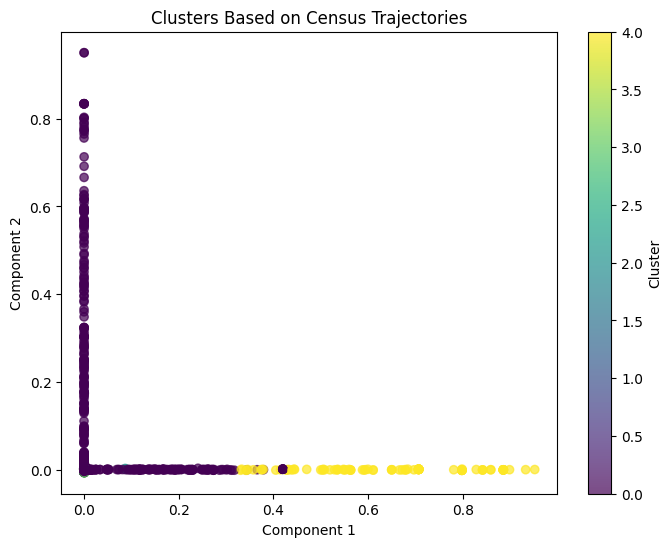


Cluster 0 sample trajectories:
0    BAERID_1559_BB_131_BH_305_BS_364_Bsys_13 BAERI...
1    BAERID_116583_BB_4787_BH_320_BS_385_Bsys_14 BA...
2    BAERID_44717_BB_4781_BH_320_BS_385_Bsys_14 BAE...
Name: trajectory, dtype: object

Cluster 1 sample trajectories:
577    BAERID_117153_BB_1132_BH_68_BS_72_Bsys_22 BAER...
580    BAERID_4327_BB_1132_BH_68_BS_72_Bsys_22 BAERID...
581    BAERID_117153_BB_1132_BH_68_BS_72_Bsys_22 BAER...
Name: trajectory, dtype: object

Cluster 2 sample trajectories:
12983    BAERID_2724_BB_344_BH_311_BS_378_Bsys_13 BAERI...
13988    BAERID_765_BB_1064_BH_63_BS_58_Bsys_21 BAERID_...
14247    BAERID_5955_BB_1074_BH_64_BS_55_Bsys_21 BAERID...
Name: trajectory, dtype: object

Cluster 3 sample trajectories:
2110    BAERID_118981_BB_1259_BH_77_BS_82_Bsys_24 BAER...
9551    BAERID_5399_BB_1315_BH_77_BS_87_Bsys_24 BAERID...
9552    BAERID_5399_BB_1315_BH_77_BS_87_Bsys_24 BAERID...
Name: trajectory, dtype: object

Cluster 4 sample trajectories:
3611    BAERID_1875_BB_50

In [7]:
# Cluster the individuals using KMeans on the 50-dimension representation.
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_clust)
df_traj['cluster'] = clusters

# -----------------------------------------------------------------------------
# Visualization: Reduce to 2D for plotting clusters.
# -----------------------------------------------------------------------------
svd_vis = TruncatedSVD(n_components=2, random_state=42)
X_vis = svd_vis.fit_transform(X_traj)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.title("Clusters Based on Census Trajectories")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

# Optionally, print a sample of trajectories for each cluster.
for cl in range(optimal_k):
    print(f"\nCluster {cl} sample trajectories:")
    print(df_traj[df_traj['cluster'] == cl]['trajectory'].head(3))